In [2]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 31.9 MB/s eta 0:00:00a 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.4 MB/s eta 0:00:0000:01


In [3]:
import nglview as nv
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [14]:
import nglview as nv
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import MMCIFParser
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline

def get_plddt_from_cif(cif_path):
    """Извлекает pLDDT (B-factor) из CIF файла"""
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", cif_path)
    plddts = []
    residues = []
    
    for residue in structure.get_residues():
        res_id = residue.id[1]
        res_name = residue.resname
        for atom in residue:
            if atom.name == "CA":  # Alpha carbon
                plddts.append(atom.bfactor)
                residues.append((res_id, res_name))
                break
    return np.array(plddts), residues


def load_af_model_and_data(folder_name, model_id=1, protein_name="", species=""):
    base = Path("/home/ilnitsky/NPM/45_Species/reannotated_species_alphafolds") / folder_name
    cif_file = base / f"{folder_name}_model_{model_id}.cif"
    conf_file = base / f"{folder_name}_summary_confidences_{model_id-1 if model_id > 0 else 0}.json"
    
    # === pLDDT per residue ===
    plddt_array, residues = get_plddt_from_cif(cif_file)
    
    # === Confidence summary ===
    try:
        with open(conf_file) as f:
            conf = json.load(f)
        ptm = conf.get('ptm')
        ranking = conf.get('ranking_score')
        frac_dis = conf.get('fraction_disordered', 0)
    except:
        ptm = ranking = frac_dis = None
    

    
    return {
        'plddt': plddt_array,
        'length': len(plddt_array),
        'protein_name': protein_name,
        'species': species,
        'ptm': ptm,
        'ranking_score': ranking,
        'fraction_disordered': frac_dis,
        'cif_path': cif_file
    }

In [ ]:
models_info = [
    {"folder": "fold_adineta_ujr31746",          "protein": "UJR31746.1",         "species": "Adineta vaga"},
    {"folder": "fold_phoronis_g980t1",           "protein": "g980.t1",            "species": "Phoronis australis"},
    {"folder": "fold_strigamia_smar003307",      "protein": "T1IQI8 / SMAR003307", "species": "Strigamia maritima"},
    {"folder": "fold_schistocerca_xp_047112766", "protein": "XP_047112766.1",     "species": "Schistocerca"},
    {"folder": "fold_monosiga_stringtie",        "protein": "Monosiga_short",      "species": "Monosiga brevicollis"},
    {"folder": "fold_trichoplax_xp_002114627_1_add_dede_exon", "protein": "TRIADDRAFT_58657 +DEDE", "species": "Trichoplax adhaerens"},
    {"folder": "fold_hydra_xp_065650130",        "protein": "XP_065650130.1",     "species": "Hydra vulgaris"},
    {"folder": "fold_callorhinchus_npm1",        "protein": "npm1",               "species": "Callorhinchus milii"},
    {"folder": "fold_callorhinchus_afp08017",    "protein": "AFP08017.1 (V9L7E8)", "species": "Callorhinchus milii"},
    {"folder": "fold_callorhinchus_xp_007904872_with_cterm", "protein": "XP_007904872.2", "species": "Callorhinchus milii"},
    {"folder": "fold_danio_rerio_np_955460_npm1a", "protein": "NP_955460.3 (npm1a)", "species": "Danio rerio"},
    {"folder": "fold_danio_rerio_np_001159627_npm1b","protein": "NP_001159627.2 (npm1b)", "species": "Danio rerio"},
    {"folder": "fold_anolis_xp_003215298",       "protein": "XP_003215298.2",     "species": "Anolis carolinensis"},
    {"folder": "fold_owenia_cah1782769_shorter_transcript",                    "protein": "CAH1782769.1 short",  "species": "Owenia fusiformis"},
    {"folder": "fold_limulus_xp_022241560",      "protein": "XP_022241560.1",     "species": "Limulus polyphemus"},
]

all_data = []
for info in models_info:
    data = load_af_model_and_data(info['folder'], protein_name=info['protein'], species=info['species'])
    all_data.append(data)

## Sequences of proteins

In [38]:
from Bio.PDB import MMCIFParser
from pathlib import Path

aa_dict = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G',
    'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
    'THR':'T','TRP':'W','TYR':'Y','VAL':'V','MSE':'M','UNK':'X'
}

def cif_to_fasta(cif_path):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", cif_path)
    sequence = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0] != ' ':
                    continue
                resname = residue.resname.strip()
                aa = aa_dict.get(resname, 'X')
                if aa:
                    sequence.append(aa)
    return ''.join(sequence)

base_dir = Path("/home/ilnitsky/NPM/45_Species/reannotated_species_alphafolds")

for info in models_info:
    folder = info['folder']

    protein = info.get('protein') or info.get('protein_name') or folder
    species = info.get('species') or info.get('Species') or "Unknown"
    
    cif_file = base_dir / folder / f"{folder}_model_1.cif"
    
    if cif_file.exists():
        seq = cif_to_fasta(cif_file)
        print(f">{protein}")
        print(seq)
        # print(f"Length: {len(seq)}\n")
    else:
        print(f"File not found: {cif_file.name}\n")

>fold_adineta_ujr31746
MREQMVLDEKIVGVELSASKKQFKWPVNDTEKKVKDNEDDDNESSDEMSALQKSFVVHSAVLGVGAKADQRNLVHLTIKDATGDKVILDQPILSLSLNKNDSISAFNLRVLLSETTEVTFKLVEGDGPVHLITSKILEPPFDFGGYSSDDDEDQFDNMSVTSDEDLPQNAGDRKAQTNLSEKTSKKSKKNPVGSVNSHTNNNNSSELQQQKKKRKKDE
>fold_phoronis_g980t1
MPVRVLRTTTVGSESSCHAPGFGELDSFKSFLWGCKLDEDHRETEFKFFRPDLEDEEDSDYIVHSLALKQACLLGDVKEVCVVEIETNNFDEEVIKQPIFSLGGHQKNCLLDLHFCQTAPLILRLIEGKGPVYISGLHQTEIPQLDEDDYGKYNDTETDLTEEDSPAKVVKKGTKRKARAAPSKRKVKKQARSEEDEEEDEEDEEEDEEEESMEEGGSVEEETEETEESQEDEEEEEEEEEEVKLPAKGVKSKKGQAKITKVDLVRDRVVLTPMGRRAVANGSAKKSGKRV
>fold_strigamia_smar003307
MFKNEQKGLNVRLGAVLVQIIRQLVTVETGTKGNPKFKQNARKANMSKEYFWGCELNETNREYTWDPEIDIQDQSEEDCYENHALILKSAMIGGTDSAVDGEINIVELETEGYLSAEVKQPILRLKCGTVDHISLDVYIPKCGILRLISGSGPVHISGQHIIEYTNDEDEGDDTKLGVVEDDEEEDEEEEEVEPEPIVEKGKRKLENGKGKPNKVAKLDDREEEYSDPESPPKNSKKKTILKGKAKAEQPTKKSKK
File not found: fold_schistocerca_xp_047112766_model_1.cif

>fold_monosiga_stringtie
MSGSESGSDMGSDINVEEMVAQVENAMGMPPTLFWGGKISKGTEVTWEPDTPFNSLSITQLALDPAAKSKTVVVQ

### Domain Boundary Delineation

Structured regions were defined as segments with pLDDT ≥ 75. Adjacent structured segments were merged into a single domain if the gap between them was 25 residues or shorter. Only domains with a minimum length of 25 residues were retained. This approach allows identification of compact folded cores while tolerating small flexible linkers.


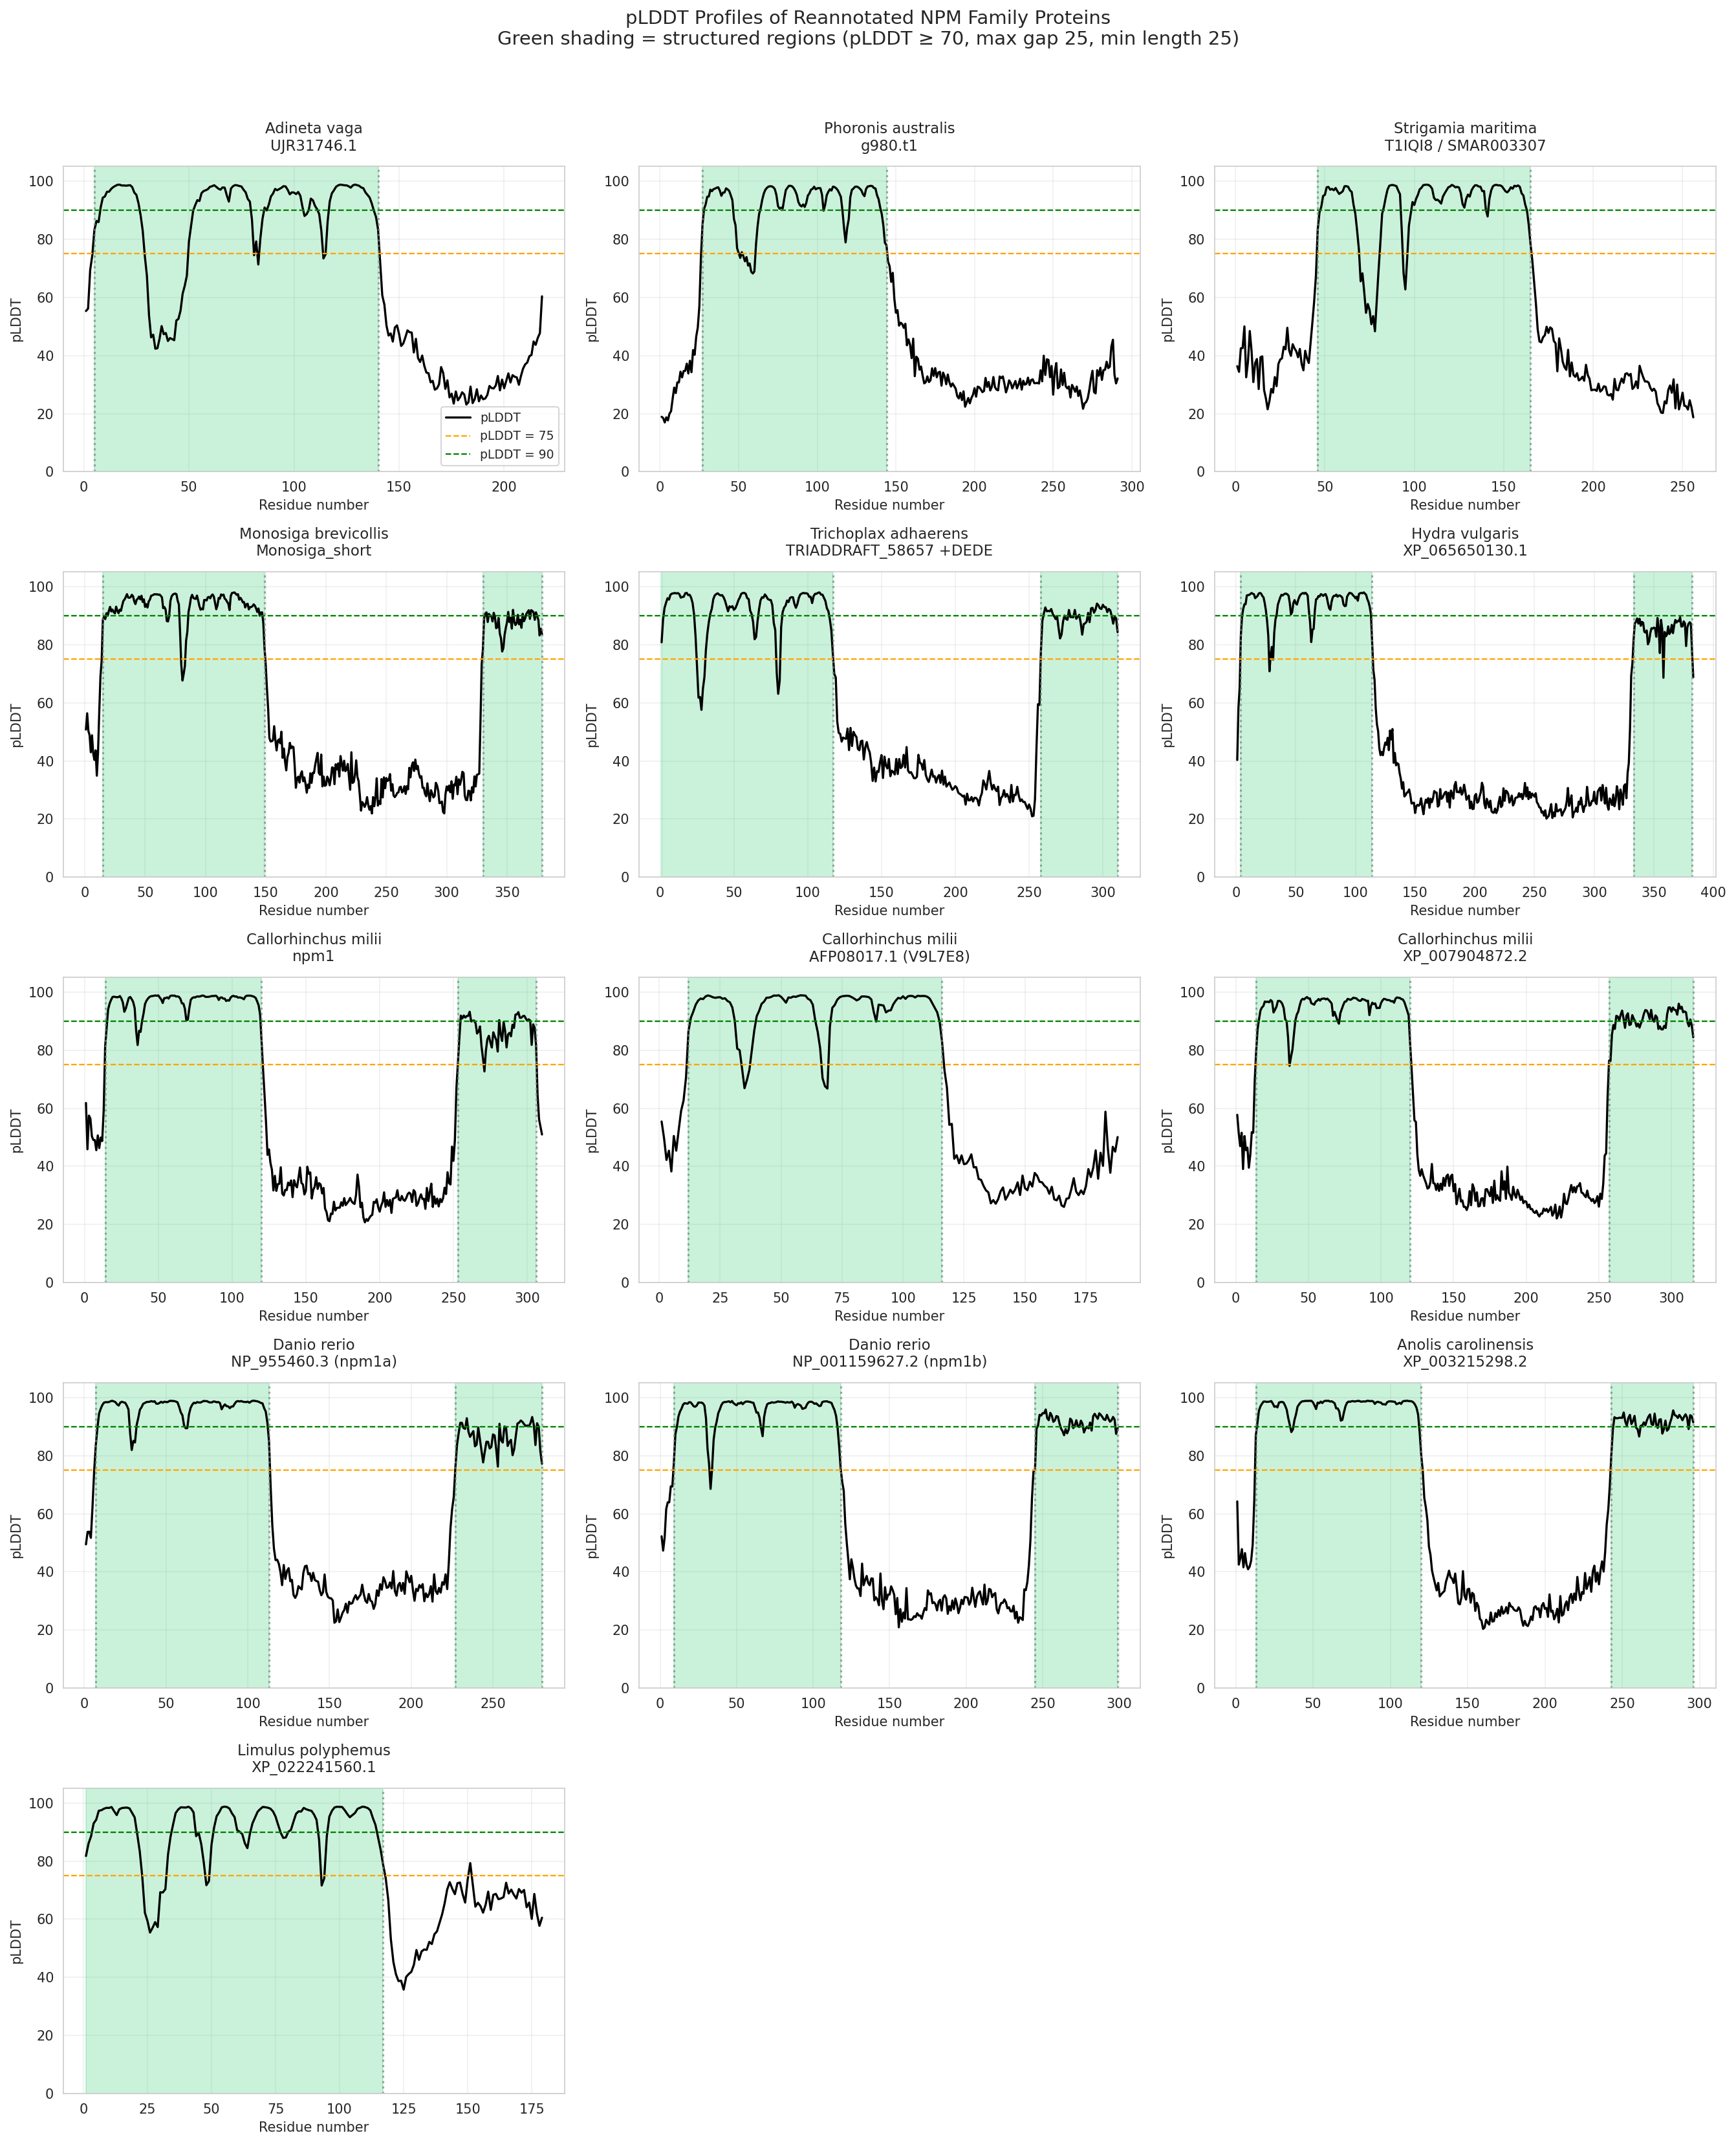

In [ ]:
import math

def find_structural_domains(plddt, threshold=70, max_gap=25, min_length=25):
    raw_domains = []
    in_domain = False
    start = 0
    
    for i, score in enumerate(plddt):
        if score >= threshold and not in_domain:
            start = i + 1
            in_domain = True
        elif score < threshold and in_domain:
            raw_domains.append((start, i))
            in_domain = False
    if in_domain:
        raw_domains.append((start, len(plddt)))
    
    if not raw_domains:
        return []
    
    merged = [list(raw_domains[0])]
    
    for current in raw_domains[1:]:
        prev = merged[-1]
        gap = current[0] - prev[1] - 1
        
        if gap <= max_gap:
            merged[-1][1] = current[1]
        else:
            merged.append(list(current))
    
    final_domains = []
    for start, end in merged:
        length = end - start + 1
        if length >= min_length:
            final_domains.append((start, end))
    
    return final_domains


n_plots = len(all_data)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

structured_color = '#2ecc71'

for i, data in enumerate(all_data):
    ax = axes[i]
    plddt = data['plddt']
    x = np.arange(1, len(plddt) + 1)
    
    ax.plot(x, plddt, color='black', linewidth=1.6, label='pLDDT')
    domains = find_structural_domains(plddt, threshold=75, max_gap=25, min_length=25)
    for start, end in domains:
        ax.axvspan(start, end, alpha=0.25, color=structured_color)
    
    ax.axhline(y=75, color='orange', linestyle='--', linewidth=1.1, label='pLDDT = 75')
    ax.axhline(y=90, color='green',  linestyle='--', linewidth=1.1, label='pLDDT = 90')
    
    for start, end in domains:
        if start > 1:
            ax.axvline(x=start, color='gray', linestyle=':', alpha=0.7)
        ax.axvline(x=end, color='gray', linestyle=':', alpha=0.7)
    
    # Formatting
    ax.set_title(f"{data['species']}\n{data['protein_name']}", fontsize=11, pad=12)
    ax.set_xlabel("Residue number", fontsize=10)
    ax.set_ylabel("pLDDT", fontsize=10)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='lower right', fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("pLDDT Profiles of Reannotated NPM Family Proteins\n"
             "Green shading = structured regions (pLDDT > 75, max gap 25, min length 25)", 
             fontsize=14, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Structured Domain coordinates

In [26]:


domain_rows = []

for data in all_data:
    domains = find_structural_domains(data['plddt'], threshold=70, max_gap=25, min_length=25)
    for j, (start, end) in enumerate(domains, 1):
        length = end - start + 1
        domain_rows.append({
            "Species": data['species'],
            "Protein": data['protein_name'],
            "Domain": j,
            "Start": start,
            "End": end,
            "Length": length
        })


df_domains = pd.DataFrame(domain_rows)
display(df_domains)

,Species,Protein,Domain,Start,End,Length
0,Adineta vaga,UJR31746.1,1,4,141,138
1,Phoronis australis,g980.t1,1,26,146,121
2,Strigamia maritima,T1IQI8 / SMAR003307,1,46,166,121
3,Monosiga brevicollis,Monosiga_short,1,14,150,137
4,Monosiga brevicollis,Monosiga_short,2,329,379,51
5,Trichoplax adhaerens,TRIADDRAFT_58657 +DEDE,1,1,117,117
6,Trichoplax adhaerens,TRIADDRAFT_58657 +DEDE,2,258,310,53
7,Hydra vulgaris,XP_065650130.1,1,4,115,112
8,Hydra vulgaris,XP_065650130.1,2,332,382,51
9,Callorhinchus milii,npm1,1,14,121,108


**Phoronis australis**  
NPM identified via BLAST against genome and proteome (gene `g980.t1`). No RefSeq/UniProt entry available. Used the original annotation from the Japanese genome assembly without modifications.


In [35]:
# Phoronis australis
view = load_af_model("fold_phoronis_g980t1", model_id=1)
view

📊 Model 1 — fold_phoronis_g980t1
   pTM          : 0.450
   Ranking Score: 0.740
   Fraction disordered: 59.00%


NGLWidget()

**Adineta vaga**  
High-quality genome. Retained original nucleoplasmin sequence `UJR31746.1` (gene `I4U23_019224`) without changes.

In [36]:
# Adineta vaga
view = load_af_model("fold_adineta_ujr31746", model_id=1)
view

📊 Model 1 — fold_adineta_ujr31746
   pTM          : 0.570
   Ranking Score: 0.790
   Fraction disordered: 44.00%


NGLWidget()

**Strigamia maritima**  
Three homologs containing the N-terminal domain were found. Only `SMAR003307` (`T1IQI8`) showed high expression and was retained. The other two (`SMAR003613`, `SMAR006417`) were discarded. Sequence taken from UniProt (no RefSeq ID available).


In [ ]:
# Strigamia maritima
view = load_af_model("fold_strigamia_smar003307", model_id=1)
view


**Schistocerca piceifrons**  
Two annotated isoforms identified (`XP_047112766.1` and `XP_047112767.1`). The longest isoform `XP_047112766.1` was selected.


In [ ]:
# Schistocerca piceifrons
view = load_af_model("fold_schistocerca_xp_047112766", model_id=1)
view


**Monosiga brevicollis**  
Used the shortened sequence derived from RNA-seq data (StringTie assembly). Only the C-terminal portion (exons 14–26) is expressed. First methionine was chosen as start.



In [ ]:
# Monosiga brevicollis
view = load_af_model("fold_monosiga_stringtie", model_id=1)
view

**Trichoplax adhaerens**  
New sequence including an additional exon with “DEDE” stretch (original gene `TRIADDRAFT_58657`). First exon adjusted to start at methionine.



In [ ]:
# Trichoplax adhaerens
view = load_af_model("fold_trichoplax_xp_002114627_1_add_dede_exon", model_id=1)
view

**Hydra vulgaris**  
Retained RefSeq sequence `XP_065650130.1` after testing additional RNA-seq datasets. Newer sequencing runs support the full transcript.



In [37]:
# Hydra vulgaris
view = load_af_model("fold_hydra_xp_065650130", model_id=1)
view

📊 Model 1 — fold_hydra_xp_065650130
   pTM          : 0.360
   Ranking Score: 0.650
   Fraction disordered: 58.00%


NGLWidget()

**Callorhinchus milii**  
Three sequences modelled:
- `npm1` — full-length with both N- and C-terminal domains.
- `AFP08017.1` (`V9L7E8`, `JW875500.1`) — annotated as nucleoplasmin/nucleoplasmin 2.
- `XP_007904872.2` (`LOC103187265`) — NPM2/3-like, truncated in IDR (used for NPM1-like C-terminal extension).


In [ ]:
# Callorhinchus milii - npm1
view = load_af_model("fold_callorhinchus_npm1", model_id=1)
view

In [ ]:
# Callorhinchus milii - AFP08017.1
view = load_af_model("fold_callorhinchus_afp08017", model_id=1)
view

In [ ]:
# Callorhinchus milii - XP_007904872.2
view = load_af_model("fold_callorhinchus_xp_007904872_with_cterm", model_id=1)
view


**Danio rerio**  
- `npm1a`: RefSeq `NP_955460.3`
- `npm1b`: `NP_001159627.2`


In [ ]:
# Danio rerio - npm1a
view = load_af_model("fold_danio_rerio_np_955460_npm1a", model_id=1)
view

In [ ]:
# Danio rerio - npm1b
view = load_af_model("fold_danio_rerio_np_001159627_npm1b", model_id=1)
view


**Anolis carolinensis**  
Used RefSeq `XP_003215298.2`.



In [ ]:
# Anolis carolinensis
view = load_af_model("fold_anolis_xp_003215298", model_id=1)
view

**Owenia fusiformis**  
Selected the shorter transcript (originally `CAH1782769.1`).


In [ ]:
# Owenia fusiformis
view = load_af_model("fold_owenia", model_id=1)
view


**Limulus polyphemus**  
Used annotated transcript `XP_022241560.1`. Consideration was given to a longer assembled transcript.

In [ ]:
# Limulus polyphemus
view = load_af_model("fold_limulus_xp_022241560", model_id=1)
view

In [ ]:
def load_af_model(folder_name, model_id=1, color='bfactor'):
    base = Path("/home/ilnitsky/NPM/45_Species/reannotated_species_alphafolds") / folder_name
    cif_file = base / f"{folder_name}_model_{model_id}.cif"
    conf_file = base / f"{folder_name}_summary_confidences_{model_id-1 if model_id > 0 else 0}.json"
    
    # === Создаём визуализацию ===
    view = nv.NGLWidget()
    comp = view.add_component(str(cif_file), default_representation=False)
    comp.add_cartoon(color_scheme=color)
    comp.add_surface(opacity=0.12, color_scheme='bfactor')
    
    # === Чтение метрик AlphaFold3 ===
    try:
        with open(conf_file) as f:
            conf = json.load(f)
        
        ptm = conf.get('ptm')
        ranking = conf.get('ranking_score')
        frac_dis = conf.get('fraction_disordered')
        
        print(f"📊 Model {model_id} — {folder_name}")
        print(f"   pTM          : {ptm:.3f}" if isinstance(ptm, (int,float)) else f"   pTM          : {ptm}")
        print(f"   Ranking Score: {ranking:.3f}" if isinstance(ranking, (int,float)) else f"   Ranking Score: {ranking}")
        print(f"   Fraction disordered: {frac_dis:.2%}" if isinstance(frac_dis, (int,float)) else f"   Fraction disordered: {frac_dis}")
        
    except FileNotFoundError:
        print(f"Confidence file not found: {conf_file.name}")
    except Exception as e:
        print(f"Error reading confidence: {e}")
    
    view.background = 'white'
    view.camera = 'orthographic'
    view.center()
    return view